## 1. Project Title
# EV Charging Station Demand, Cost and Customer Behavior Analysis Using Python

## 2. Project Overview
### Objective
Electric vehicle adoption is growing faster than charging infrastructure is being
built, so operators need to know when demand arrives, what drives cost, and
where capacity is under strain. This project analyses 8,354 real-world-style EV
charging sessions to answer those questions and to convert the findings into
operational recommendations.
### Business questions
1. How does charging demand vary across the hours of the day, and when does it peak?
2. Does demand behave differently on weekdays and weekends?
3. Which vehicle types and which stations account for the most demand?
4. What drives the cost of a charging session?
5. What causes customers to wait, and how long do they wait?

## 3. Dataset Description
| Item | Detail |
|---|---|
| Records | 8,354 charging sessions |
| Original columns | 27 |
| Columns after feature engineering | 32 |


## 4. Tools and Technologies

4.1 **Programming Language**   
Python                       
4.2 **Libraries**    
Pandas                                    
NumPy                                  
Matplotlib                               
Seaborn                        
Plotly                          
4.3 **Development Environment**                      
Jupyter Notebook

## 5. Methodology

#### 5. Data Collection
**Data Source:** Kaggle               
**Dataset Format:** CSV  

The dataset used in this project was obtained from Kaggle and contains information about Electric Vehicle (EV) charging sessions, including vehicle type, energy consumption, charging cost, waiting time, demand, weather, and time-related factors. The dataset was downloaded in CSV format and imported into Jupyter Notebook using Pandas for further data cleaning, analysis, and visualization.

#### 5.1 Import Required Libraries

The required Python libraries are imported for data manipulation and numerical analysis. Pandas is used to load and manage the dataset, while NumPy is used for numerical calculations and data processing.

In [1]:
import pandas as pd
import numpy as np

#### 5.2 Data Loading
Load the Raw Dataset   - 
The raw Electric Vehicle (EV) charging dataset is loaded into a Pandas DataFrame. Each row represents an individual EV charging session, while the columns contain information about the vehicle, charging activity, station conditions, and environmental factors.

In [2]:
df = pd.read_csv("ev_charging_dataset.csv")
print("Dataset loaded successfully!")

Dataset loaded successfully!


The dataset was successfully loaded without errors and is ready for initial inspection.

#### 5.3 Data Understanding
Dataset Shape  - 
The shape of the dataset is examined to determine the total number of observations and variables.
The raw dataset contains 8,354 rows and 27 columns, providing a sufficiently large dataset for exploratory data analysis and visualization.

In [3]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 8354
Number of Columns: 27


In [4]:
df.head()

,timestamp,station_id,location_type,vehicle_id,vehicle_type,arrival_time,charging_start_time,charging_end_time,waiting_time,battery_capacity_kWh,...,electricity_price,renewable_energy_ratio,traffic_density,weather_condition,day_of_week,time_slot,charging_demand,assigned_charger_id,charging_priority,optimization_reward
0,2025-01-01 00:00:00,ST004,Urban,EV10000,Two-Wheeler,2025-01-01 00:00:00,2025-01-01 00:12:00,2025-01-01 04:33:00,12,60,...,13.66,0.280335,Low,Cloudy,Wednesday,Off-Peak,17.242398,CH4,Low,-8.622299
1,2025-01-01 00:15:00,ST005,Urban,EV10001,Two-Wheeler,2025-01-01 00:15:00,2025-01-01 00:23:00,2025-01-01 01:12:00,8,100,...,5.47,0.392127,Low,Rainy,Wednesday,Off-Peak,18.324933,CH9,Low,-1.935644
2,2025-01-01 00:30:00,ST019,Highway,EV10002,Car,2025-01-01 00:30:00,2025-01-01 00:41:00,2025-01-01 01:35:00,11,75,...,9.50,0.103979,Low,Clear,Wednesday,Off-Peak,36.028168,CH2,Low,-18.201846
3,2025-01-01 00:45:00,ST008,Urban,EV10003,Two-Wheeler,2025-01-01 00:45:00,2025-01-01 00:54:00,2025-01-01 03:29:00,9,40,...,6.22,0.248553,Low,Clear,Wednesday,Off-Peak,17.146935,CH9,Medium,-7.404018
4,2025-01-01 01:00:00,ST008,Highway,EV10004,Two-Wheeler,2025-01-01 01:00:00,2025-01-01 01:08:00,2025-01-01 06:14:00,8,75,...,13.42,0.234926,Low,Cloudy,Wednesday,Off-Peak,14.577768,CH1,Low,-6.577466


In [5]:
df.tail()

,timestamp,station_id,location_type,vehicle_id,vehicle_type,arrival_time,charging_start_time,charging_end_time,waiting_time,battery_capacity_kWh,...,electricity_price,renewable_energy_ratio,traffic_density,weather_condition,day_of_week,time_slot,charging_demand,assigned_charger_id,charging_priority,optimization_reward
8349,2025-03-28 23:15:00,ST011,Urban,EV18349,Bus,2025-03-28 23:15:00,2025-03-28 23:28:00,2025-03-28 23:52:00,13,30,...,14.67,0.131198,Low,Clear,Friday,Off-Peak,24.557664,CH6,Low,-15.495699
8350,2025-03-28 23:30:00,ST019,Urban,EV18350,Two-Wheeler,2025-03-28 23:30:00,2025-03-28 23:42:00,2025-03-29 00:50:00,12,30,...,8.24,0.126224,Low,Cloudy,Friday,Off-Peak,33.027807,CH2,Medium,-14.885047
8351,2025-03-28 23:45:00,ST005,Highway,EV18351,Bus,2025-03-28 23:45:00,2025-03-28 23:55:00,2025-03-29 07:00:00,10,75,...,9.90,0.370010,Low,Cloudy,Friday,Off-Peak,27.381072,CH7,Medium,-5.713488
8352,2025-03-29 00:00:00,ST014,Highway,EV18352,Two-Wheeler,2025-03-29 00:00:00,2025-03-29 00:22:00,2025-03-29 01:45:00,22,40,...,14.85,0.105252,Low,Cloudy,Saturday,Off-Peak,25.138820,CH1,High,-27.040944
8353,2025-03-29 00:15:00,ST020,Urban,EV18353,Two-Wheeler,2025-03-29 00:15:00,2025-03-29 00:34:00,2025-03-29 01:26:00,19,60,...,7.53,0.246519,Low,Clear,Saturday,Off-Peak,33.177527,CH10,Low,-22.667824


Initial Data Inspection  - 
The first five records are displayed using the head() function to understand the structure, column names, and types of information contained in the EV charging dataset.

The dataset includes temporal, vehicle, charging, station, environmental, and operational variables.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8354 entries, 0 to 8353
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   timestamp               8354 non-null   object 
 1   station_id              8354 non-null   object 
 2   location_type           8354 non-null   object 
 3   vehicle_id              8354 non-null   object 
 4   vehicle_type            8354 non-null   object 
 5   arrival_time            8354 non-null   object 
 6   charging_start_time     8354 non-null   object 
 7   charging_end_time       8354 non-null   object 
 8   waiting_time            8354 non-null   int64  
 9   battery_capacity_kWh    8354 non-null   int64  
 10  initial_soc             8354 non-null   float64
 11  final_soc               8354 non-null   float64
 12  energy_consumed_kWh     8354 non-null   float64
 13  charging_power_kW       8354 non-null   int64  
 14  charging_duration       8354 non-null   

#### 5.4 Data Cleaning
Dataset Information and Data Types  - 
The info() function is used to examine the dataset structure, number of non-null records, and data types of each variable.
All 8,354 records are non-null across the 27 columns. The dataset contains numerical variables stored as integer and floating-point types, while categorical and date/time fields are initially stored as object data types.
The date/time columns require conversion to an appropriate datetime format for accurate time-based analysis.

#### 5.4.1 Missing Value Analysis  
Missing values are checked across all columns to determine whether data imputation or removal is required.
The analysis identified no missing values in any of the 27 columns. Therefore, no missing-value imputation or row removal was required at this stage.

In [7]:
missing_values = df.isnull().sum()

print(missing_values)

timestamp                 0
station_id                0
location_type             0
vehicle_id                0
vehicle_type              0
arrival_time              0
charging_start_time       0
charging_end_time         0
waiting_time              0
battery_capacity_kWh      0
initial_soc               0
final_soc                 0
energy_consumed_kWh       0
charging_power_kW         0
charging_duration         0
queue_length              0
station_load              0
electricity_price         0
renewable_energy_ratio    0
traffic_density           0
weather_condition         0
day_of_week               0
time_slot                 0
charging_demand           0
assigned_charger_id       0
charging_priority         0
optimization_reward       0
dtype: int64


#### 5.4.2 Duplicate Record Analysis 
The dataset is checked for completely duplicated records because duplicate observations can lead to inaccurate analytical results.
The analysis identified 0 duplicate rows. Therefore, no duplicate records were removed from the dataset.

In [8]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


#### 5.4.3 Column Name Inspection  
All column names are displayed to understand the available variables and establish the basis for subsequent cleaning, validation, and feature-engineering steps.
The dataset contains 27 original variables covering charging sessions, vehicle characteristics, station operations, energy consumption, and contextual conditions.

In [9]:
print(df.columns.tolist())

['timestamp', 'station_id', 'location_type', 'vehicle_id', 'vehicle_type', 'arrival_time', 'charging_start_time', 'charging_end_time', 'waiting_time', 'battery_capacity_kWh', 'initial_soc', 'final_soc', 'energy_consumed_kWh', 'charging_power_kW', 'charging_duration', 'queue_length', 'station_load', 'electricity_price', 'renewable_energy_ratio', 'traffic_density', 'weather_condition', 'day_of_week', 'time_slot', 'charging_demand', 'assigned_charger_id', 'charging_priority', 'optimization_reward']


#### 5.4.4 Date and Time Conversion 
The timestamp and charging-related time variables are converted from object format into Pandas datetime format.

The following columns are converted:
- timestamp
- arrival_time
- charging_start_time
- charging_end_time
This transformation enables reliable time-based calculations and supports later analysis of charging duration, peak hours, daily patterns, and charging demand.

In [10]:
date_columns = [
    "timestamp",
    "arrival_time",
    "charging_start_time",
    "charging_end_time"
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors="coerce")

#### 5.4.5 Verification of Date/Time Conversion  
The data types of the converted columns are verified to ensure that the transformation was successful.
All four selected columns are now stored as datetime64[ns], confirming that the date/time conversion was completed successfully.

In [11]:
df[date_columns].dtypes

timestamp              datetime64[ns]
arrival_time           datetime64[ns]
charging_start_time    datetime64[ns]
charging_end_time      datetime64[ns]
dtype: object

#### 5.5 Data Validation
Validation of Converted Date/Time Columns - 
After converting the date/time variables, the columns are checked for invalid or unrecognized date values.
The validation returned 0 missing datetime values across all four columns. Therefore, the conversion was successful and no further correction was required.

In [12]:
df[date_columns].isnull().sum()

timestamp              0
arrival_time           0
charging_start_time    0
charging_end_time      0
dtype: int64

#### 5.5.1 Categorical Data Analysis  
The categorical variables are examined using frequency counts to identify the unique categories and their distribution.
The dataset contains valid categories across station, location, vehicle type, traffic density, weather, day of week, time slot, charger, and charging priority. No missing categorical values were identified.
This analysis provides an initial understanding of the composition of the EV charging sessions.

In [13]:
categorical_columns = [
    "station_id",
    "location_type",
    "vehicle_type",
    "traffic_density",
    "weather_condition",
    "day_of_week",
    "time_slot",
    "assigned_charger_id",
    "charging_priority"
]
for col in categorical_columns:
    print("\n", col)
    print(df[col].value_counts())


 station_id
station_id
ST013    459
ST001    443
ST005    438
ST017    434
ST011    432
ST003    431
ST019    427
ST012    421
ST009    417
ST015    416
ST006    413
ST014    412
ST020    412
ST018    412
ST010    406
ST004    405
ST008    400
ST002    398
ST007    391
ST016    387
Name: count, dtype: int64

 location_type
location_type
Urban      4188
Highway    4166
Name: count, dtype: int64

 vehicle_type
vehicle_type
Car            2833
Two-Wheeler    2761
Bus            2760
Name: count, dtype: int64

 traffic_density
traffic_density
Low       3134
High      3132
Medium    2088
Name: count, dtype: int64

 weather_condition
weather_condition
Rainy     2854
Cloudy    2760
Clear     2740
Name: count, dtype: int64

 day_of_week
day_of_week
Wednesday    1248
Thursday     1248
Friday       1248
Saturday     1154
Sunday       1152
Monday       1152
Tuesday      1152
Name: count, dtype: int64

 time_slot
time_slot
Off-Peak    5222
Peak        3132
Name: count, dtype: int64

 assigned_cha

#### 5.5.2 Numerical Variable Identification 
The numerical variables are identified to prepare the dataset for statistical analysis, validation, and visualization.
The dataset contains 13 numerical variables, including waiting time, battery capacity, State of Charge, energy consumption, charging power, charging duration, queue length, station load, electricity price, renewable energy ratio, charging demand, and optimization reward.

In [14]:
numerical_columns = df.select_dtypes(include=np.number).columns

print(numerical_columns.tolist())

['waiting_time', 'battery_capacity_kWh', 'initial_soc', 'final_soc', 'energy_consumed_kWh', 'charging_power_kW', 'charging_duration', 'queue_length', 'station_load', 'electricity_price', 'renewable_energy_ratio', 'charging_demand', 'optimization_reward']


#### 5.5.3 Statistical Summary of Numerical Variables  
Descriptive statistics are generated using the describe() function to understand the central tendency, variability, and range of the numerical variables.
These statistics provide a baseline understanding of the EV charging data before further exploratory analysis.

In [15]:
df[numerical_columns].describe()

,waiting_time,battery_capacity_kWh,initial_soc,final_soc,energy_consumed_kWh,charging_power_kW,charging_duration,queue_length,station_load,electricity_price,renewable_energy_ratio,charging_demand,optimization_reward
count,8354.000000,8354.000000,8354.000000,8354.000000,8354.000000,8354.000000,8354.000000,8354.000000,8354.000000,8354.000000,8354.000000,8354.000000,8354.000000
mean,9.526335,61.079722,34.808452,98.495545,39.079746,22.449126,178.700376,4.591573,53.177399,9.959945,0.354101,53.156126,-11.834559
std,4.894049,25.001163,14.478839,3.258039,18.973883,16.813449,149.120567,2.828987,27.380740,2.878798,0.186150,27.563387,9.271940
min,0.000000,30.000000,10.000582,65.079759,7.502195,7.000000,10.000000,0.000000,10.053024,5.000000,0.100157,5.505723,-43.285910
25%,6.000000,40.000000,22.371986,98.463666,23.675251,11.000000,64.118008,3.000000,28.029710,7.510000,0.207315,27.911603,-18.354606
50%,9.000000,60.000000,34.638994,99.998223,35.148384,11.000000,133.700252,5.000000,49.421293,9.955000,0.313459,49.513337,-11.268337
75%,13.000000,75.000000,47.310647,100.000000,51.363447,22.000000,247.946169,7.000000,77.600445,12.397500,0.462315,77.845036,-5.106912
max,28.000000,100.000000,59.992462,100.000000,89.929089,50.000000,776.551110,15.000000,100.000000,15.000000,0.799922,104.985659,14.176434


#### 5.5.4 State of Charge (SOC) Validation  
The initial and final State of Charge (SOC) values are validated to ensure that they remain within the logical range of 0% to 100%.
The validation identified 0 invalid initial SOC values and 0 invalid final SOC values. Therefore, no SOC corrections were required.

In [16]:
print("Invalid Initial SOC:",
      ((df["initial_soc"] < 0) | (df["initial_soc"] > 100)).sum())

print("Invalid Final SOC:",
      ((df["final_soc"] < 0) | (df["final_soc"] > 100)).sum())

Invalid Initial SOC: 0
Invalid Final SOC: 0


#### 5.5.5 Waiting Time Validation  
Waiting time is checked for negative values because a negative waiting duration would represent an invalid charging-session record.
The analysis identified 0 negative waiting-time values, indicating that the waiting-time data is logically valid.

In [17]:
print(
    "Negative waiting time:",
    (df["waiting_time"] < 0).sum()
)

Negative waiting time: 0


#### 5.5.6 Queue Length Validation  
Queue length is validated to ensure that no negative values are present.
The analysis identified 0 negative queue-length values, confirming that the queue information is within a valid logical range.

In [18]:
print(
    "Negative queue length:",
    (df["queue_length"] < 0).sum()
)

Negative queue length: 0


#### 5.5.7 Charging Power Validation
Charging power is checked for zero or negative values because a valid charging session should have a positive charging power.
The analysis identified 0 invalid charging-power values, indicating that all recorded charging sessions have valid positive charging power.

In [19]:
print(
    "Invalid charging power:",
    (df["charging_power_kW"] <= 0).sum()
)

Invalid charging power: 0


#### 5.5.8 Energy Consumption Validation  
Energy consumption is checked to ensure that all charging sessions contain positive energy usage values.
The analysis identified 0 invalid energy-consumption values. Therefore, no corrections were required for this variable.

In [20]:
print(
    "Invalid energy consumption:",
    (df["energy_consumed_kWh"] <= 0).sum()
)

Invalid energy consumption: 0


#### 5.5.9 Station Load Validation
Station load is validated against the expected range of 0% to 100%.
The analysis identified 0 invalid station-load values, confirming that all station-load observations fall within the expected range.

In [21]:
invalid_load = (
    (df["station_load"] < 0) |
    (df["station_load"] > 100)
).sum()

print("Invalid station load:", invalid_load)

Invalid station load: 0


#### 5.5.10 Renewable Energy Ratio Validation 
The renewable energy ratio is checked to ensure that all values fall within the logical range of 0 to 1.
The analysis identified 0 invalid renewable energy ratio values. Therefore, no corrections were necessary.

In [22]:
invalid_ratio = (
    (df["renewable_energy_ratio"] < 0) |
    (df["renewable_energy_ratio"] > 1)
).sum()

print("Invalid renewable energy ratio:", invalid_ratio)

Invalid renewable energy ratio: 0


#### 5.5.11 Charging Time Consistency Check 
The chronological relationship between arrival time, charging start time, and charging end time is validated.
The analysis identified 0 sessions where charging started before arrival and 0 sessions where charging ended before charging started. Therefore, the recorded time sequence is logically consistent.

In [23]:
invalid_start = (
    df["charging_start_time"] < df["arrival_time"]
).sum()

invalid_end = (
    df["charging_end_time"] < df["charging_start_time"]
).sum()

print("Charging started before arrival:", invalid_start)
print("Charging ended before charging started:", invalid_end)

Charging started before arrival: 0
Charging ended before charging started: 0


#### 5.5.12 Independent Charging Duration Calculation 
This calculated duration is used to validate the existing charging_duration variable and ensure consistency between the recorded timestamps and the duration value.

In [24]:
calculated_duration = (
    df["charging_end_time"] -
    df["charging_start_time"]
).dt.total_seconds() / 60

#### 5.5.13 Charging Duration Validation  
The independently calculated charging duration is compared with the existing charging_duration column.
The maximum observed difference is approximately 1 minute, indicating that the recorded charging duration is highly consistent with the charging start and end timestamps.
Therefore, the existing charging-duration values are retained without modification.

In [25]:
duration_difference = (
    calculated_duration - df["charging_duration"]
).abs()

print("Maximum difference:",
      duration_difference.max())

Maximum difference: 0.9999808303639952


## 6. Feature Engineering

Feature engineering is performed to create meaningful analytical variables from the existing dataset.
The newly derived features are designed to support analysis of battery charging behavior, charging demand, customer waiting experience, and charging cost.

The following features are created:
- SOC Increase
- Arrival Hour
- Day Type
- Charging Cost
- Waiting Category

#### 6.1 SOC Increase

The soc_increase feature represents the change in battery State of Charge during a charging session.
It is calculated as:

**SOC Increase = Final SOC − Initial SOC**

This feature helps measure how much the vehicle battery was charged during each session.

In [26]:
#Feature Engineering
#SOC Increase
df["soc_increase"] = (
    df["final_soc"] - df["initial_soc"]
)

#### 6.2 Arrival Hour

The arrival_hour feature is extracted from the vehicle arrival timestamp.
This feature converts the arrival time into an hour value, making it easier to identify peak and off-peak charging patterns throughout the day.

In [27]:
#Arrival Hour
df["arrival_hour"] = df["arrival_time"].dt.hour

#### 6.3 Day Type

The day_type feature classifies each charging session as either Weekday or Weekend based on the arrival date.
This feature enables comparison of EV charging behavior between regular working days and weekends.

In [28]:
#Day Type
df["day_type"] = df["arrival_time"].dt.dayofweek.map(
    lambda x: "Weekend" if x >= 5 else "Weekday"
)

#### 6.4 Charging Cost

The charging_cost feature estimates the cost associated with each charging session.

It is calculated as:

Charging Cost = Energy Consumed × Electricity Price

Charging cost is estimated by multiplying energy consumed (kWh) by electricity price per kWh.

In [29]:
#Charging Cost
df["charging_cost"] = (
    df["energy_consumed_kWh"] *
    df["electricity_price"]
)

#### 6.5 Waiting Category

The waiting_category feature groups charging-session waiting times into three categories: Short, Medium, and Long.

This categorization helps simplify the analysis of customer waiting experience and charging-station congestion.

In [30]:
#Waiting Category
df["waiting_category"] = pd.cut(
    df["waiting_time"],
    bins=[-1, 10, 30, np.inf],
    labels=["Short", "Medium", "Long"]
)

## 7. Final Dataset Validation

After completing the data cleaning, validation, and feature-engineering steps, the final dataset structure is checked.

The dataset retains all 8,354 original records and increases from 27 original columns to 32 columns after the creation of five successfully added features in the current notebook output.

The cleaned and enhanced dataset is now ready for Exploratory Data Analysis (EDA) and visualization.

In [31]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])


Rows: 8354
Columns: 32


Cleaned dataset Loading

In [32]:
df.to_csv("EV_Charging_Cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


## 8. Exploratory Data Analysis (EDA) and Visualisation


In [33]:
# Visualisation libraries
# matplotlib -> base plots | seaborn -> statistical plots | plotly -> interactive charts
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [34]:
# Load the cleaned EV charging dataset
df = pd.read_csv("EV_Charging_Cleaned.csv")
print("Cleaned Dataset loaded successfully!")

Cleaned Dataset loaded successfully!


### 8.1 Count of Charging Sessions by Vehicle Type
**EDA Type: Univariate Analysis**                      
**Chart Type: Bar Chart**                 
This visualization shows the number of charging sessions for each vehicle type. It helps us understand which types of electric vehicles are most commonly represented in the dataset.

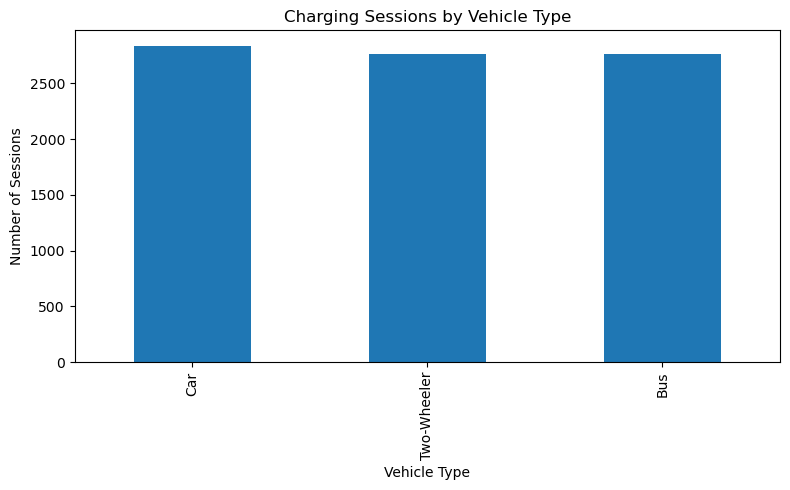

In [35]:
# 1: Count of charging sessions by vehicle type
plt.figure(figsize=(8, 5))
df["vehicle_type"].value_counts().plot(kind="bar")
plt.title("Charging Sessions by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Number of Sessions")
plt.tight_layout()
plt.show()

#### Observation-
The three vehicle categories are almost evenly represented. Cars have the highest number of sessions with 2,833, followed by Two-Wheelers with 2,761 and Buses with 2,760. The difference between the largest and smallest category is only 73 sessions.
#### Business Meaning-
The balanced representation makes the vehicle-type comparisons more reliable because no single vehicle category dominates the dataset.

### 8.2 Distribution of Charging Cost
**EDA Type: Univariate Analysis**                   
**Chart Type: Histogram**                            
This visualization shows how charging costs are distributed across all charging sessions. It helps identify the most common charging cost range, the spread of costs, and any unusually high or low values.

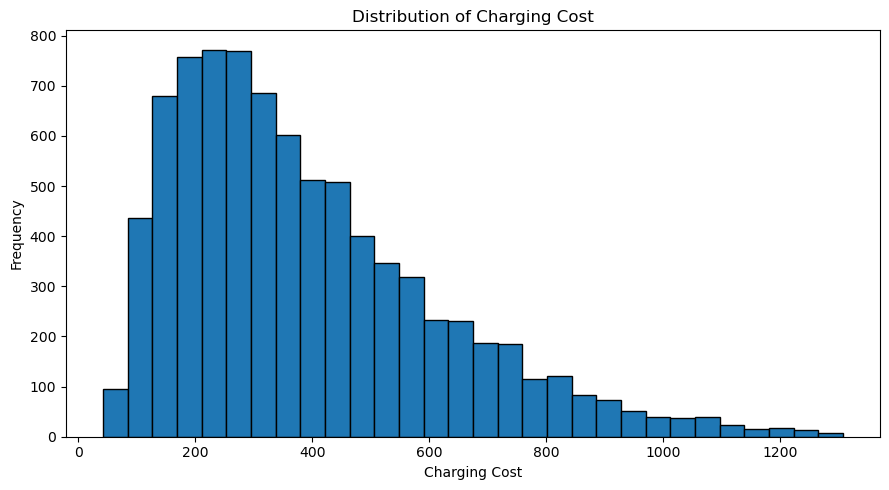

In [36]:
# 2: Distribution of charging cost
plt.figure(figsize=(9, 5))
plt.hist(df["charging_cost"], bins=30, edgecolor="black")
plt.title("Distribution of Charging Cost")
plt.xlabel("Charging Cost")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

#### Observation-
The histogram shows the distribution of charging costs across all charging sessions. Most charging sessions are concentrated within a relatively common cost range, while higher-cost sessions occur less frequently.
#### Business Meaning-
Understanding the cost distribution can help charging-station operators monitor typical customer spending and identify unusually high-cost charging sessions.

### 8.3 Charging Sessions by Weather Condition
**EDA Type: Univariate Analysis**                      
**Chart Type: Bar Chart**                                      
This visualization shows the number of EV charging sessions recorded under different weather conditions. It helps us understand how the charging sessions are distributed across various weather conditions.

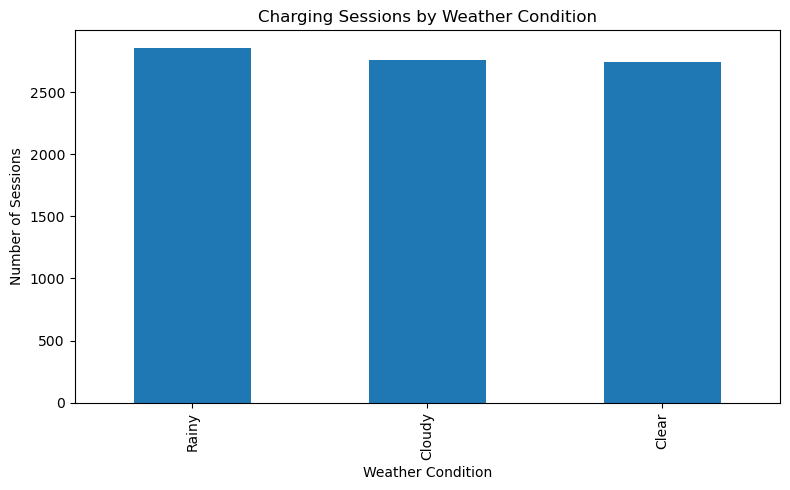

In [37]:
# 3: Charging sessions by weather condition
plt.figure(figsize=(8, 5))
df["weather_condition"].value_counts().plot(kind="bar")
plt.title("Charging Sessions by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Number of Sessions")
plt.tight_layout()
plt.show()

#### Observation-
Charging sessions are distributed across the different weather conditions in the dataset without a major difference in overall activity between weather categories.
#### Business Meaning-
Weather does not appear to be a major driver of charging-session volume in this dataset. Therefore, operational planning should focus more strongly on other factors, particularly time of day.

### 8.4 Charging Sessions by Day of Week
**EDA Type: Univariate Analysis**                            
**Chart Type: Bar Chart**                               
This visualization shows the number of charging sessions recorded on each day of the week. It helps identify which days have higher or lower charging activity and understand weekly usage patterns.

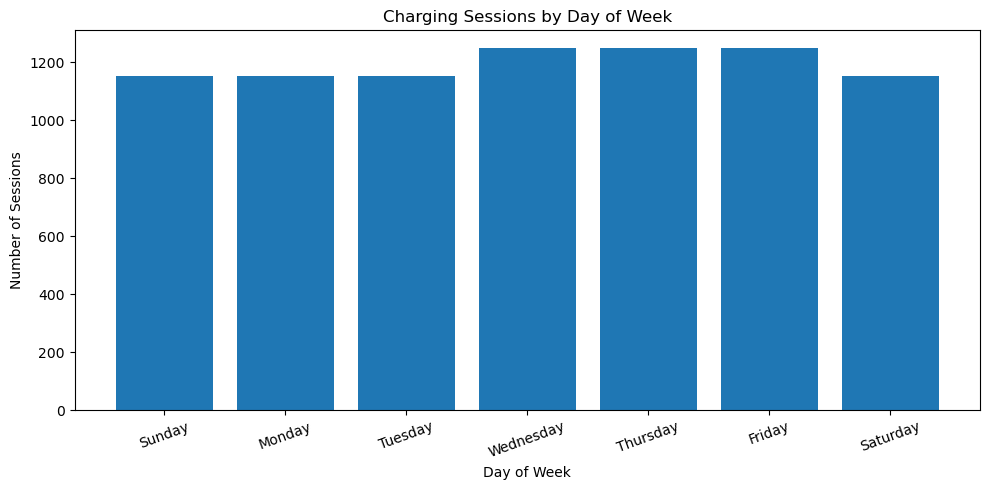

In [38]:
# 4: Charging Sessions by Day of Week

day_order = [
    "Sunday", "Monday", "Tuesday",
    "Wednesday", "Thursday", "Friday", "Saturday"
]

day_counts = df["day_of_week"].value_counts().reindex(day_order)

plt.figure(figsize=(10, 5))

plt.bar(day_counts.index, day_counts.values)

plt.title("Charging Sessions by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Sessions")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

#### Observation-
Charging activity is distributed across the days of the week, with no major difference between individual days.
#### Business Meaning-
Since charging activity does not show a strong weekly-day pattern, station resources should not be planned solely around a particular day of the week.

### 8.5 Charging Sessions by Station
**EDA Type: Univariate Analysis**                              
**Chart Type: Horizontal Bar Chart**                                    
This visualization shows the number of charging sessions recorded at each charging station. It helps identify which stations have the highest and lowest usage and provides an overview of station-level demand.

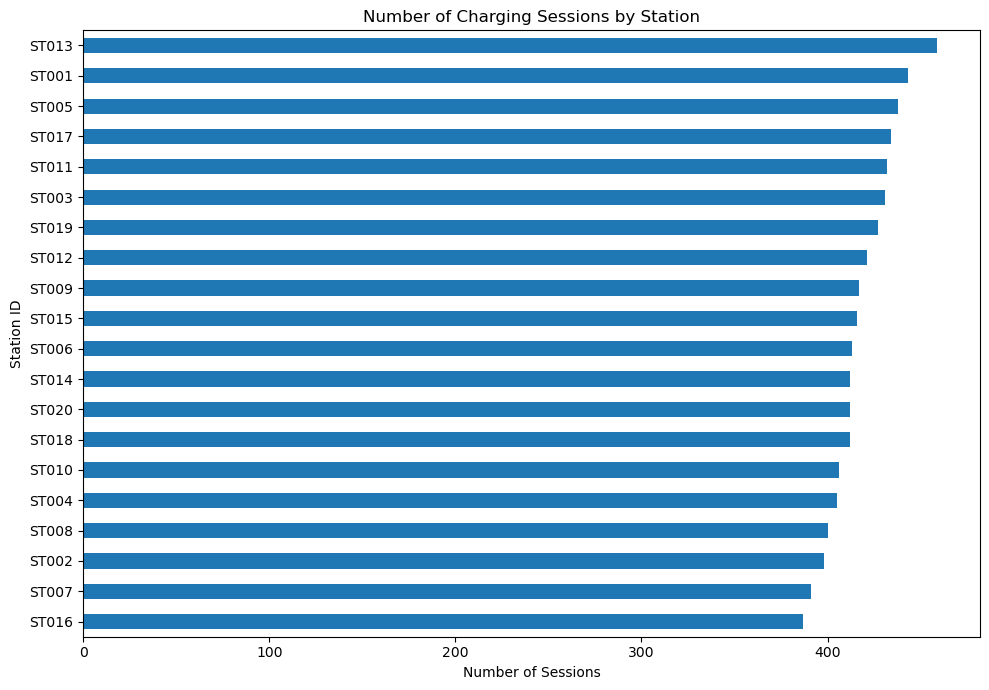

In [39]:
# 5: Charging sessions by station
station_counts = df["station_id"].value_counts().sort_values(ascending=True)

plt.figure(figsize=(10, 7))
station_counts.plot(kind="barh")
plt.title("Number of Charging Sessions by Station")
plt.xlabel("Number of Sessions")
plt.ylabel("Station ID")
plt.tight_layout()
plt.show()

#### Observation-
The horizontal bar chart shows the number of charging sessions recorded at each station. It highlights differences in station-level usage and identifies stations with relatively higher or lower activity.
#### Business Meaning-
Stations with higher session volumes may require closer monitoring of charger availability and operational capacity, while lower-volume stations can be evaluated for resource optimization.

### 8.6 Charging Cost by Vehicle Type
**EDA Type: Bivariate Analysis**                         
**Chart Type: Box Plot**                              
This visualization compares the distribution of charging costs across different vehicle types. The box plot helps identify differences in typical charging costs, variation, and potential outliers for each vehicle type.

<Figure size 900x500 with 0 Axes>

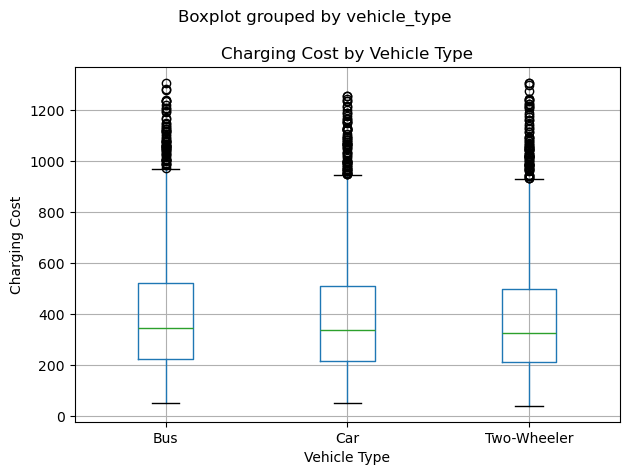

In [40]:
# 6: Charging cost by vehicle type
plt.figure(figsize=(9, 5))
df.boxplot(column="charging_cost", by="vehicle_type")
plt.title("Charging Cost by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Charging Cost")
plt.tight_layout()
plt.show()

#### Observation-
Charging costs vary across vehicle types. Buses have the highest average charging cost at 396.70, while the differences between vehicle categories are relatively moderate.
#### Business Meaning-
Vehicle type can influence charging expenditure. Operators can use this information for cost planning and for understanding which customer segments generate higher charging costs.

### 8.7 Relationship Between Energy Consumed and Charging Cost
**EDA Type: Bivariate Analysis**                         
**Chart Type: Scatter Plot**                                     
This visualization examines the relationship between the amount of energy consumed during a charging session and its charging cost. Vehicle type is used as an additional category to identify differences between vehicle types.

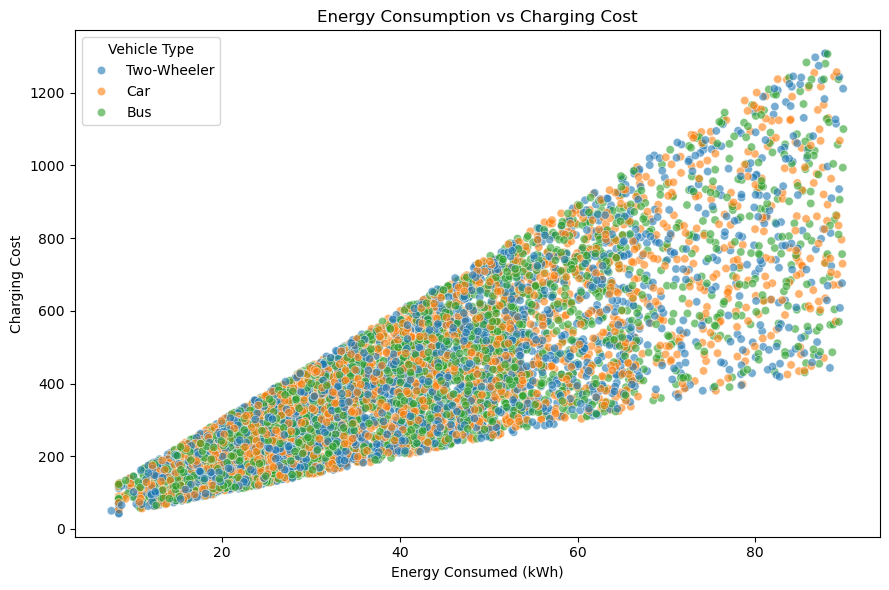

In [41]:
# 7: Relationship between energy consumed and charging cost
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df,x="energy_consumed_kWh",y="charging_cost",hue="vehicle_type",alpha=0.6)
plt.title("Energy Consumption vs Charging Cost")
plt.xlabel("Energy Consumed (kWh)")
plt.ylabel("Charging Cost")
plt.legend(title="Vehicle Type")
plt.tight_layout()
plt.show()

#### Observation-
The scatter plot shows a positive relationship between energy consumed and charging cost: charging sessions that consume more energy generally have higher calculated charging costs. Buses also show the highest average energy consumption at 39.45 kWh.
#### Business Meaning-
Energy consumption is an important factor in charging cost. Monitoring energy usage can therefore help operators understand cost patterns and support appropriate pricing and energy-management strategies.

### 8.8 Queue Length v/s Waiting Time
**EDA Type: Bivariate Analysis**                                   
**Chart Type: Scatter Plot**                                      
This visualization examines the relationship between the number of vehicles waiting in the queue and the waiting time for a charging session. The location type is used as an additional category to compare patterns across different locations.

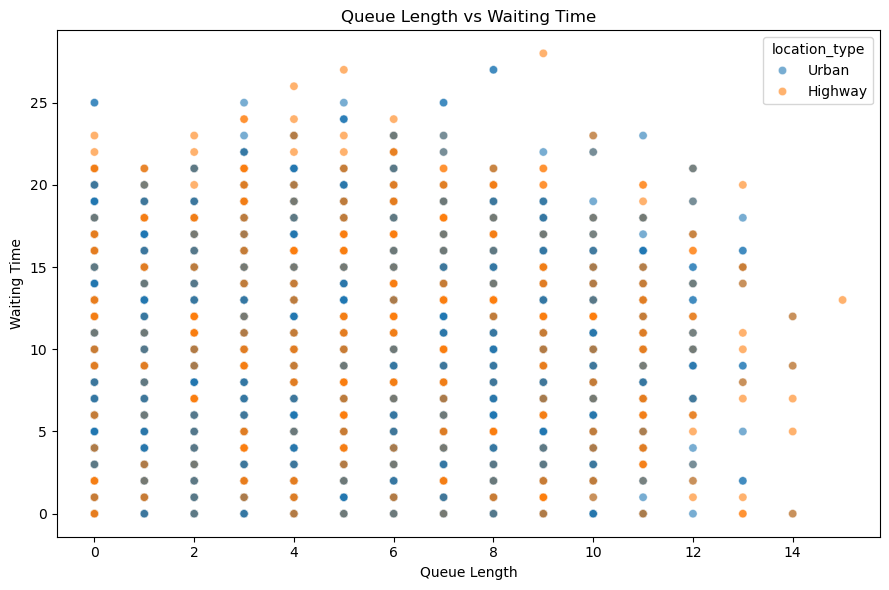

In [42]:
# 8: Queue length v/s waiting time
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df,x="queue_length",y="waiting_time",hue="location_type",alpha=0.6)
plt.title("Queue Length vs Waiting Time")
plt.xlabel("Queue Length")
plt.ylabel("Waiting Time")
plt.tight_layout()
plt.show()

#### Observation-
The scatter plot compares queue length with waiting time across different location types. The relationship is not strongly defined, indicating that a longer visible queue does not completely explain customer waiting time.
#### Business Meaning-
This suggests that waiting time may also be influenced by operational factors such as charger availability, charging duration, customer processing, or other station-level delays. Therefore, operators should investigate the complete customer waiting process rather than focusing only on queue length.

### 8.9 Charging Duration by Priority
**EDA Type: Bivariate Analysis**                            
**Chart Type: Box Plot**                              
This visualization compares charging duration across different charging priority levels. The box plot helps identify differences in the typical charging duration, variation, and potential outliers for low, medium, and high priority charging sessions.

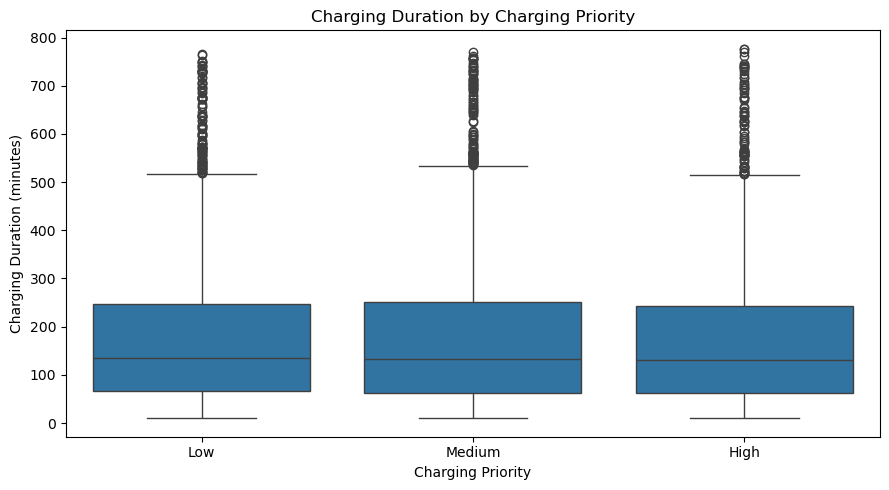

In [43]:
# 9: Charging duration by priority
priority_order = ["Low", "Medium", "High"]

plt.figure(figsize=(9, 5))
sns.boxplot(data=df,x="charging_priority",y="charging_duration",
    order=[p for p in priority_order if p in df["charging_priority"].unique()]
)
plt.title("Charging Duration by Charging Priority")
plt.xlabel("Charging Priority")
plt.ylabel("Charging Duration (minutes)")
plt.tight_layout()
plt.show()

#### Observation-
Charging duration varies across the different charging-priority levels. The box plot also shows the spread and possible variation in charging duration within each priority category.
#### Business Meaning-
Understanding charging duration by priority can help operators manage charger allocation and determine whether priority customers are receiving the expected operational advantage.

### 8.10 Average Charging Demand by Vehicle Type
**EDA Type: Bivariate Analysis**                                            
**Chart Type: Plotly Bar Chart**                                          
This visualization compares the average charging demand across different vehicle types. It helps identify which vehicle types are associated with higher or lower average charging demand.

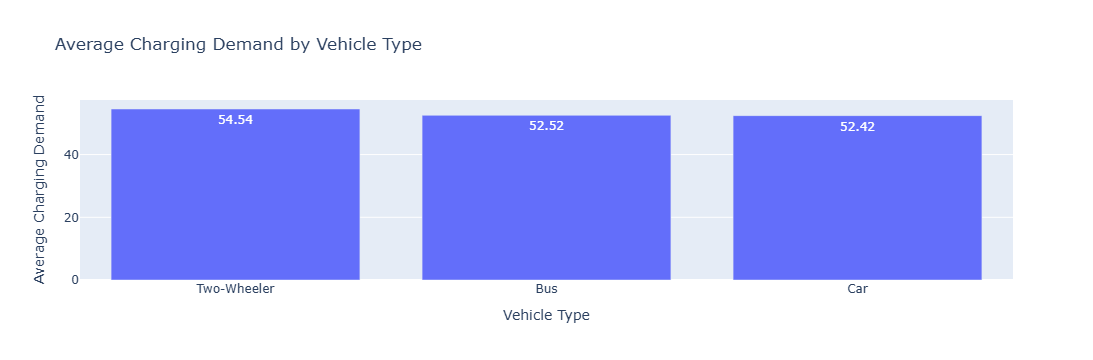

In [44]:
# 10: Average Charging Demand by Vehicle Type 
vehicle_demand = ( 
    df.groupby("vehicle_type", as_index=False)
        ["charging_demand"] .mean()
        .sort_values("charging_demand", ascending=False)
) 
fig = px.bar( 
    vehicle_demand, 
    x="vehicle_type", 
    y="charging_demand", 
    title="Average Charging Demand by Vehicle Type", 
    text_auto=".2f" 
) 
fig.update_layout( 
    xaxis_title="Vehicle Type", 
    yaxis_title="Average Charging Demand" 
) 
fig.show()

#### Observation-
Average charging demand differs across vehicle categories. Two-Wheelers have the highest average charging demand at 54.54, making them the highest-demand vehicle type in the dataset.
#### Business Meaning-
Vehicle type should be considered when planning charging capacity and understanding customer demand. However, vehicle type is not the only factor affecting demand.

### 8.11 Average Charging Demand by Arrival Hour
**EDA Type: Bivariate Analysis**                              
**Chart Type: Line Chart**                                   
This visualization shows how the average charging demand changes throughout the day based on the arrival hour. It helps identify peak and low-demand periods and understand the daily pattern of EV charging activity.

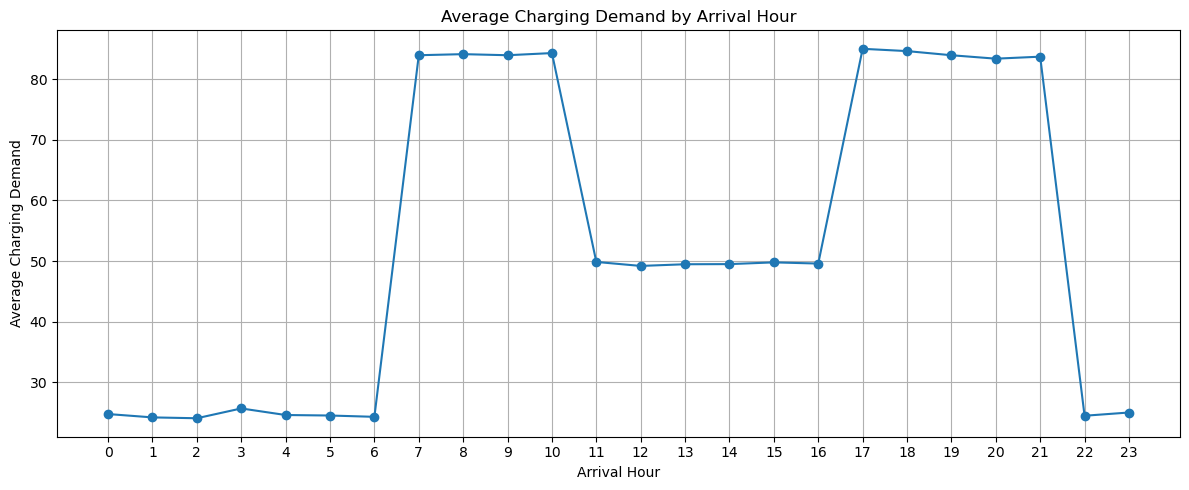

In [45]:
# 11: Average Charging Demand by Arrival Hour
hourly_demand = (
    df.groupby("arrival_hour")["charging_demand"]
    .mean()
    .reindex(range(24))
)

plt.figure(figsize=(12, 5))

plt.plot(
    hourly_demand.index,
    hourly_demand.values,
    marker="o"
)

plt.title("Average Charging Demand by Arrival Hour")
plt.xlabel("Arrival Hour")
plt.ylabel("Average Charging Demand")

plt.xticks(range(24))

plt.grid(True)

plt.tight_layout()
plt.show()

#### Observation-
Charging demand changes considerably throughout the day. The highest average charging demand occurs around 5:00 PM, while the lowest occurs around 2:00 AM.
#### Business Meaning-
This clearly indicates a time-based demand pattern. Charging stations can use peak-hour information to improve charger availability, staffing, and operational planning.

### 8.12 Demand by Day Type and Time Slot 
**EDA Type: Multivariate Analysis**                                         
**Chart Type: Grouped Bar Chart**                                          
This visualization compares the average charging demand across different day types and time slots. It helps identify when charging demand is highest and whether demand patterns change between different types of days.

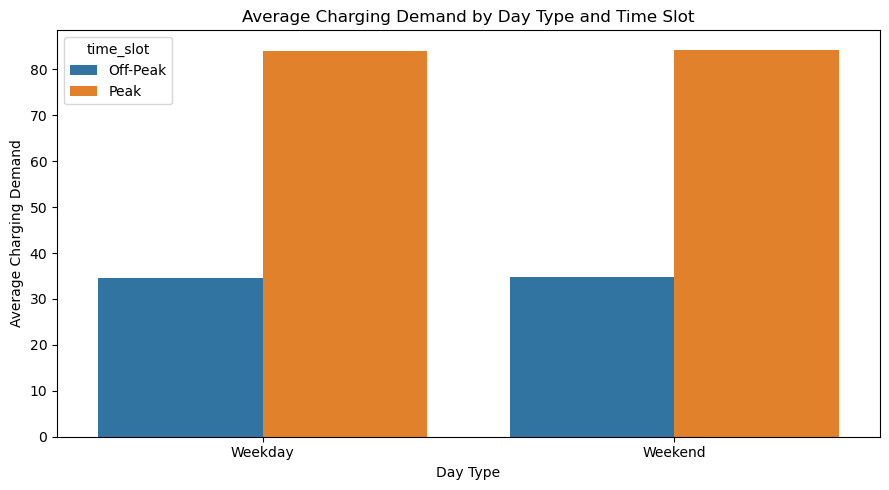

  day_type time_slot  charging_demand
0  Weekday  Off-Peak        34.527195
1  Weekday      Peak        84.024032
2  Weekend  Off-Peak        34.794671
3  Weekend      Peak        84.274378


In [46]:
# 12: Demand by day type and time slot 
demand_day_slot = ( 
    df.groupby(["day_type", "time_slot"], as_index=False)
        ["charging_demand"] 
        .mean() 
) 
plt.figure(figsize=(9, 5)) 
sns.barplot( 
    data=demand_day_slot, 
    x="day_type", 
    y="charging_demand", 
    hue="time_slot" 
) 
plt.title("Average Charging Demand by Day Type and Time Slot") 
plt.xlabel("Day Type") 
plt.ylabel("Average Charging Demand") 
plt.tight_layout() 
plt.show() 
print(demand_day_slot)

#### Observation-
The grouped bar chart shows that charging demand varies more noticeably across different time slots than between weekdays and weekends. Peak periods show higher demand, while off-peak periods show lower demand.
#### Business Meaning-
The results suggest that time of day is more useful than simply classifying a day as weekday or weekend when planning charging capacity and operational resources.

### 8.13 Average Charging Demand by Hour and Vehicle Type
**EDA Type: Multivariate Analysis**                          
**Chart Type: Plotly Line Chart**                              
This visualization shows how average charging demand changes throughout the day for different vehicle types. It helps compare the daily demand patterns of each vehicle type and identify differences in peak charging periods.

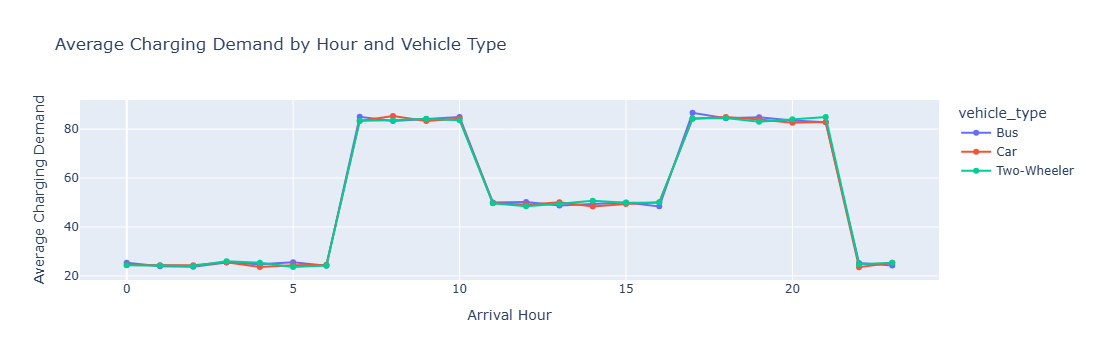

In [47]:
# 13: Average Charging Demand by Hour and Vehicle Type 
hourly_vehicle = ( 
    df.groupby( 
        ["arrival_hour", "vehicle_type"], 
        as_index=False )
        ["charging_demand"] 
        .mean() 
)
fig = px.line( 
    hourly_vehicle, 
    x="arrival_hour", 
    y="charging_demand", 
    color="vehicle_type", 
    markers=True, 
    title="Average Charging Demand by Hour and Vehicle Type" 
) 
fig.update_layout( 
    xaxis_title="Arrival Hour", 
    yaxis_title="Average Charging Demand" 
) 
fig.show()

#### Observation-
The daily demand pattern changes across vehicle types, but the overall pattern still shows that charging demand varies substantially according to arrival hour. This indicates that time-based variation is more prominent than vehicle-type differences alone.
#### Business Meaning-
Charging operators should combine vehicle type and arrival time when planning capacity. However, the strongest operational focus should remain on identifying and preparing for peak hours.

### 8.14 Correlation Heatmap for Important Numerical Variables
**EDA Type: Multivariate Analysis**                    
**Chart Type: Correlation Heatmap**                                  
This heatmap shows the correlation between important numerical variables in the EV charging dataset. It helps identify strong positive and negative relationships between variables and provides an overall view of how different charging metrics are related to each other.

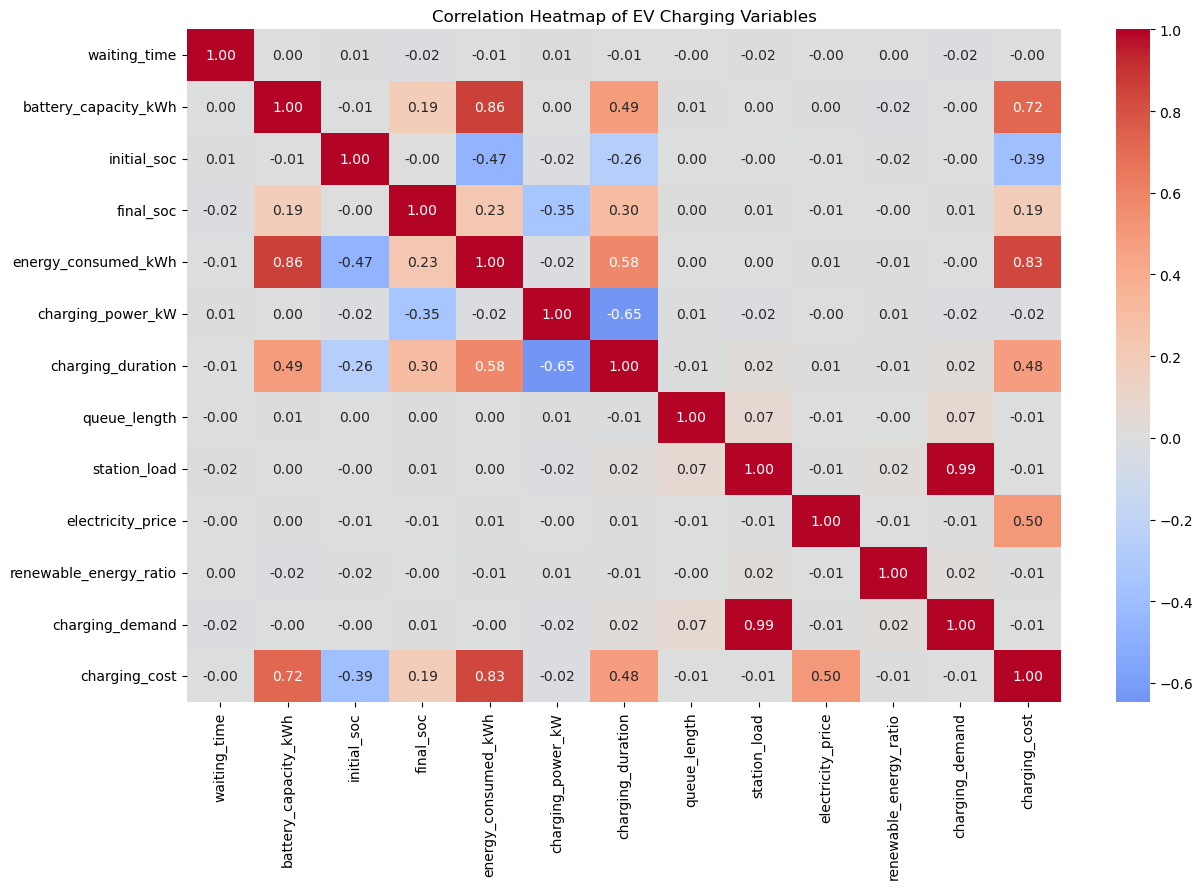

In [49]:
# 14: Correlation heatmap for important numerical variables

corr_cols = [
    "waiting_time",
    "battery_capacity_kWh",
    "initial_soc",
    "final_soc",
    "energy_consumed_kWh",
    "charging_power_kW",
    "charging_duration",
    "queue_length",
    "station_load",
    "electricity_price",
    "renewable_energy_ratio",
    "charging_demand",
    "charging_cost"
]

# Calculate correlation
corr = df[corr_cols].corr()

# Create heatmap
plt.figure(figsize=(13, 9))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of EV Charging Variables")
plt.tight_layout()
plt.show()

#### Observation-
The correlation heatmap provides an overall view of relationships among the important numerical variables. It helps identify which charging-related variables move together and which have relatively weak relationships.
#### Business Meaning-
The heatmap helps identify variables that may be useful for further analysis and helps avoid assuming relationships that are not supported by the data.

## 9. Final Analysis – Statistical Summary and Key Findings

After completing the Exploratory Data Analysis (EDA), the next step is to identify the main patterns and findings from the EV charging dataset.

The analysis focuses on charging demand, energy consumption, charging cost, waiting time, vehicle type, arrival time, day type, and charging station performance. The statistical summaries and visualisations help identify important trends and support useful business recommendations.

## Key Insights

9.1  **Cars** have the highest number of charging sessions with **2,833 sessions**, followed by Two-Wheelers (2,761) and Buses (2,760).

9.2  **Buses** have the highest average energy consumption at **39.45 kWh**, while Two-Wheelers have the lowest at **38.71 kWh**.

9.3  **Buses** have the highest average charging cost at **396.70**, showing that their charging sessions are slightly more expensive on average.

9.4  **Two-Wheelers** have the highest average charging demand at **54.54**, making them the highest-demand vehicle type in the dataset.

9.5  **Bus users** have the highest average waiting time at **9.61 minutes**, while Two-Wheeler users have the lowest at **9.43 minutes**.

9.6  **Time of day** has the strongest observed pattern in charging demand. Demand is highest around **5:00 PM** and lowest around **2:00 AM**. This shows that charging demand changes more with time than with vehicle type, weather, or day type.

9.7  **Weather conditions and day of the week** show relatively small differences in charging-session volume in this dataset.

## 10. Recommendations

**10.1 Plan staff and charging capacity by time**  
   Increase staff and charging capacity during busy hours, especially **7:00–11:00 AM** and **5:00–9:00 PM**.  
   *Based on: Time-of-day demand analysis.*

**10.2 Offer off-peak discounts**  
   Provide lower prices during **11:00 AM–4:00 PM** and overnight to encourage charging during less busy periods.  
   *Based on: Peak and off-peak demand analysis.*

**10.3 Investigate waiting time**  
   **Investigate station-level operational factors** such as charger allocation, charging duration, and station utilization to understand the additional factors contributing to customer waiting time.                          
   *Based on: Queue length and waiting time analysis.*

**10.4 Encourage shorter charging during peak hours**  
   Encourage efficient charging during peak hours by promoting shorter charging sessions where operationally appropriate.                                     
   *Based on: SOC and charging-duration analysis.*

**10.5 Review investment and priority planning**  
   Focus mainly on **time-based demand** rather than weather or vehicle type. Also, check whether the **charging priority system** is working effectively.  
   *Based on: Station, vehicle type, weather, and priority analysis.*

## 11. Conclusion

The analysis of 8,354 EV charging sessions shows that time of day is the main factor affecting charging demand. Demand is highest around 5:00 PM and lowest around 2:00 AM. Vehicle type, weather, and day type have much smaller effects. Therefore, EV charging stations should focus on time-based staffing, capacity planning, and pricing. Off-peak discounts and better management of busy hours can help reduce peak-time pressure and improve the overall charging experience.